In [1]:
# ====================== 2. NẠP THƯ VIỆN ======================
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'medium'
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [2]:
# ====================== 3. LOAD DATA ======================
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/2321004016_VuNgocLinh_DoAn/data/data.csv'

raw_dataset = pd.read_csv(DATA_PATH, encoding='latin1')
raw_dataset.columns = [col.encode('ascii', 'ignore').decode() for col in raw_dataset.columns]

print('=== KÍCH THƯỚC DỮ LIỆU GỐC ===')
print(f'Số dòng: {raw_dataset.shape[0]:,} | Số cột: {raw_dataset.shape[1]}')
display(raw_dataset.head())

=== KÍCH THƯỚC DỮ LIỆU GỐC ===
Số dòng: 541,909 | Số cột: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom


In [3]:
# ====================== 4. CÁC HÀM HỖ TRỢ ======================
def load_and_clean_data(path):
    df = pd.read_csv(path, encoding='latin1')
    df.columns = [col.encode('ascii', 'ignore').decode() for col in df.columns]
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

    df = df.dropna(subset=['CustomerID']).copy()
    df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
    df = df[~df['InvoiceNo'].astype(str).str.startswith('C')].copy()
    df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
    return df

def build_rfm_features(df):
    reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
    rfm = (
        df.groupby('CustomerID')
        .agg(
            Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
            Frequency=('InvoiceNo', 'nunique'),
            Monetary=('TotalAmount', 'sum'),
        )
        .reset_index()
    )
    return rfm

def standardize_features(feature_frame):
    raw = np.log1p(feature_frame[['Recency', 'Frequency', 'Monetary']].to_numpy(dtype=float))
    means = raw.mean(axis=0)
    stds = raw.std(axis=0, ddof=0)
    stds[stds == 0] = 1.0
    return (raw - means) / stds

def kmeans_plus_plus_init(data, k, rng):
    n_samples = data.shape[0]
    centroids = np.empty((k, data.shape[1]), dtype=float)

    first_idx = rng.integers(0, n_samples)
    centroids[0] = data[first_idx]
    closest_dist_sq = np.sum((data - centroids[0]) ** 2, axis=1)

    for centroid_idx in range(1, k):
        probs = closest_dist_sq / closest_dist_sq.sum()
        next_idx = rng.choice(n_samples, p=probs)
        centroids[centroid_idx] = data[next_idx]
        new_dist_sq = np.sum((data - centroids[centroid_idx]) ** 2, axis=1)
        closest_dist_sq = np.minimum(closest_dist_sq, new_dist_sq)

    return centroids

def run_kmeans(data, k, random_state=42, max_iter=200, n_init=10):
    best_labels = None
    best_centroids = None
    best_inertia = np.inf

    for init_idx in range(n_init):
        rng = np.random.default_rng(random_state + init_idx)
        centroids = kmeans_plus_plus_init(data, k, rng)

        for _ in range(max_iter):
            distances = np.linalg.norm(data[:, None, :] - centroids[None, :, :], axis=2)
            labels = distances.argmin(axis=1)

            new_centroids = np.vstack([
                data[labels == cluster_id].mean(axis=0)
                if np.any(labels == cluster_id)
                else data[rng.integers(0, len(data))]
                for cluster_id in range(k)
            ])

            if np.allclose(centroids, new_centroids, atol=1e-6):
                centroids = new_centroids
                break

            centroids = new_centroids

        distances = np.linalg.norm(data - centroids[labels], axis=1) ** 2
        inertia = float(distances.sum())

        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.copy()
            best_centroids = centroids.copy()

    return best_labels, best_centroids, best_inertia

def silhouette_score_numpy(data, labels):
    unique_labels = np.unique(labels)
    if unique_labels.size < 2:
        return float('nan')

    distance_matrix = np.linalg.norm(data[:, None, :] - data[None, :, :], axis=2)
    silhouettes = np.zeros(data.shape[0], dtype=float)

    for idx in range(data.shape[0]):
        same_cluster = labels == labels[idx]
        same_cluster[idx] = False

        if np.any(same_cluster):
            a_i = distance_matrix[idx, same_cluster].mean()
        else:
            silhouettes[idx] = 0.0
            continue

        b_i = np.inf
        for other_label in unique_labels:
            if other_label == labels[idx]:
                continue
            other_cluster = labels == other_label
            if np.any(other_cluster):
                b_i = min(b_i, distance_matrix[idx, other_cluster].mean())

        silhouettes[idx] = (b_i - a_i) / max(a_i, b_i)

    return float(silhouettes.mean())

def evaluate_k_range(data, k_values):
    rows = []
    for k in k_values:
        labels, _, inertia = run_kmeans(data, k)
        silhouette = silhouette_score_numpy(data, labels)
        rows.append({'k': k, 'inertia': inertia, 'silhouette': silhouette})
    return pd.DataFrame(rows)

def score_segment(row):
    if row['RecencyScore'] >= 4 and row['FrequencyScore'] >= 4 and row['MonetaryScore'] >= 4:
        return 'Best Customers'
    if row['RecencyScore'] >= 4 and row['FrequencyScore'] >= 3:
        return 'Loyal Customers'
    if row['RecencyScore'] >= 3 and row['MonetaryScore'] >= 4:
        return 'Big Spenders'
    if row['RecencyScore'] <= 2 and row['FrequencyScore'] >= 3:
        return 'At Risk'
    return 'Regular Customers'

def add_business_labels(rfm):
    labelled = rfm.copy()
    labelled['RecencyScore'] = pd.qcut(labelled['Recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]).astype(int)
    labelled['FrequencyScore'] = pd.qcut(labelled['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
    labelled['MonetaryScore'] = pd.qcut(labelled['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
    labelled['RuleBasedSegment'] = labelled.apply(score_segment, axis=1)
    return labelled

def build_cluster_profile(rfm):
    return (
        rfm.groupby('Cluster')
        .agg(
            Customers=('CustomerID', 'count'),
            AvgRecency=('Recency', 'mean'),
            AvgFrequency=('Frequency', 'mean'),
            AvgMonetary=('Monetary', 'mean'),
            MedianMonetary=('Monetary', 'median'),
        )
        .sort_values('AvgMonetary', ascending=False)
        .round(2)
        .reset_index()
    )

def load_clean_transactions(path):
    df = pd.read_csv(path, encoding='latin1')
    df.columns = [col.encode('ascii', 'ignore').decode() for col in df.columns]
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    df = df.dropna(subset=['CustomerID']).copy()
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
    df = df[~df['InvoiceNo'].astype(str).str.startswith('C')].copy()
    df['Revenue'] = df['Quantity'] * df['UnitPrice']
    return df

def build_monthly_features(df):
    monthly = (
        df.assign(MonthStart=df['InvoiceDate'].dt.to_period('M').dt.to_timestamp())
        .groupby('MonthStart')
        .agg(
            Revenue=('Revenue', 'sum'),
            Orders=('InvoiceNo', 'nunique'),
            ActiveCustomers=('CustomerID', 'nunique'),
            Quantity=('Quantity', 'sum'),
        )
        .reset_index()
        .sort_values('MonthStart')
    )

    last_timestamp = df['InvoiceDate'].max()
    current_month_start = last_timestamp.to_period('M').to_timestamp()
    if last_timestamp.day < last_timestamp.days_in_month:
        monthly = monthly[monthly['MonthStart'] < current_month_start].copy()

    monthly['MonthLabel'] = monthly['MonthStart'].dt.strftime('%Y-%m')
    return monthly

def linear_forecast(series, steps):
    y = series.to_numpy(dtype=float)
    x = np.arange(len(y), dtype=float)
    slope, intercept = np.polyfit(x, y, deg=1)
    future_x = np.arange(len(y), len(y) + steps, dtype=float)
    predictions = intercept + slope * future_x
    predictions = np.maximum(predictions, 0.0)
    return predictions, float(slope)

def build_forecast_table(monthly, steps=3):
    metric_names = ['Revenue', 'Orders', 'ActiveCustomers', 'Quantity']
    future_months = pd.date_range(monthly['MonthStart'].max() + pd.offsets.MonthBegin(1), periods=steps, freq='MS')

    forecast_df = pd.DataFrame({'MonthStart': future_months})
    slopes = {}

    for metric in metric_names:
        preds, slope = linear_forecast(monthly[metric], steps)
        forecast_df[metric] = np.round(preds, 2)
        slopes[metric] = slope

    forecast_df['MonthLabel'] = forecast_df['MonthStart'].dt.strftime('%Y-%m')
    return forecast_df, slopes

def classify_trend(slope):
    if slope > 0:
        return 'Tăng'
    if slope < 0:
        return 'Giảm'
    return 'Ổn định'

In [4]:
# ====================== 5. KHÁM PHÁ DỮ LIỆU (EDA) ======================
print('=== THÔNG TIN TỔNG QUAN ===')
print(raw_dataset.info())

print('\n=== GIÁ TRỊ THIẾU ===')
display(raw_dataset.isnull().sum().sort_values(ascending=False).to_frame('Missing'))

raw_dataset['InvoiceDate'] = pd.to_datetime(raw_dataset['InvoiceDate'])
raw_dataset['Revenue'] = raw_dataset['Quantity'] * raw_dataset['UnitPrice']

print('\n=== MỘT SỐ THỐNG KÊ NHANH ===')
print('Số hóa đơn hủy:', raw_dataset['InvoiceNo'].astype(str).str.startswith('C').sum())
print('Số dòng Quantity <= 0:', (raw_dataset['Quantity'] <= 0).sum())
print('Số dòng UnitPrice <= 0:', (raw_dataset['UnitPrice'] <= 0).sum())
print('Số dòng thiếu CustomerID:', raw_dataset['CustomerID'].isna().sum())

=== THÔNG TIN TỔNG QUAN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

=== GIÁ TRỊ THIẾU ===


,Missing
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0



=== MỘT SỐ THỐNG KÊ NHANH ===
Số hóa đơn hủy: 9288
Số dòng Quantity <= 0: 10624
Số dòng UnitPrice <= 0: 2517
Số dòng thiếu CustomerID: 135080


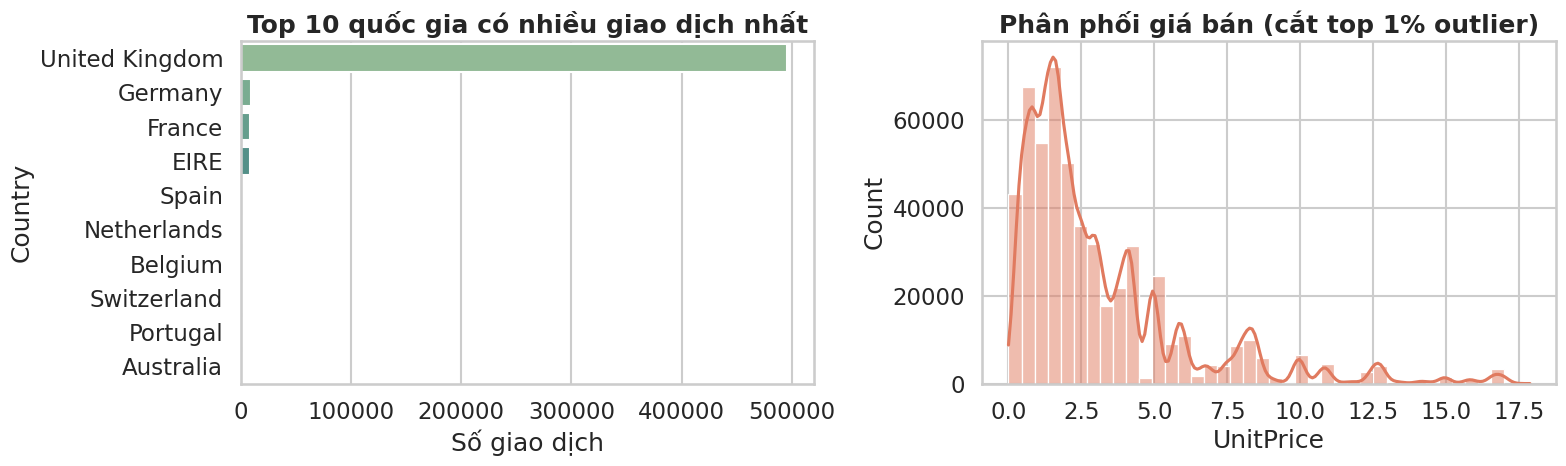

In [5]:
# ====================== 6. TRỰC QUAN HÓA BAN ĐẦU ======================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

country_top = raw_dataset['Country'].value_counts().head(10)
sns.barplot(x=country_top.values, y=country_top.index, palette='crest', ax=axes[0])
axes[0].set_title('Top 10 quốc gia có nhiều giao dịch nhất')
axes[0].set_xlabel('Số giao dịch')
axes[0].set_ylabel('Country')

price_sample = raw_dataset.loc[raw_dataset['UnitPrice'] > 0, 'UnitPrice']
sns.histplot(price_sample[price_sample < price_sample.quantile(0.99)], bins=40, kde=True, color='#E07A5F', ax=axes[1])
axes[1].set_title('Phân phối giá bán (cắt top 1% outlier)')
axes[1].set_xlabel('UnitPrice')

plt.tight_layout()
plt.show()

In [6]:
# ====================== 7. TIỀN XỬ LÝ & FEATURE ENGINEERING ======================
dataset = load_and_clean_data(DATA_PATH)
dataset['Year'] = dataset['InvoiceDate'].dt.year
dataset['Month'] = dataset['InvoiceDate'].dt.month
dataset['DayOfWeek'] = dataset['InvoiceDate'].dt.dayofweek
dataset['IsWeekend'] = dataset['DayOfWeek'].isin([5, 6]).astype(int)

rfm_dataset = build_rfm_features(dataset)
rfm_dataset = add_business_labels(rfm_dataset)

print('=== DỮ LIỆU SAU KHI LÀM SẠCH ===')
print(f'Số giao dịch còn lại: {len(dataset):,}')
print(f'Số khách hàng dùng để phân cụm: {len(rfm_dataset):,}')
display(rfm_dataset.head())

=== DỮ LIỆU SAU KHI LÀM SẠCH ===
Số giao dịch còn lại: 397,884
Số khách hàng dùng để phân cụm: 4,338


,CustomerID,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RuleBasedSegment
0,12346,326,1,"77,183.60",1,1,5,Regular Customers
1,12347,2,7,"4,310.00",5,5,5,Best Customers
2,12348,75,4,"1,797.24",2,4,4,At Risk
3,12349,19,1,"1,757.55",4,1,4,Big Spenders
4,12350,310,1,334.40,1,1,2,Regular Customers


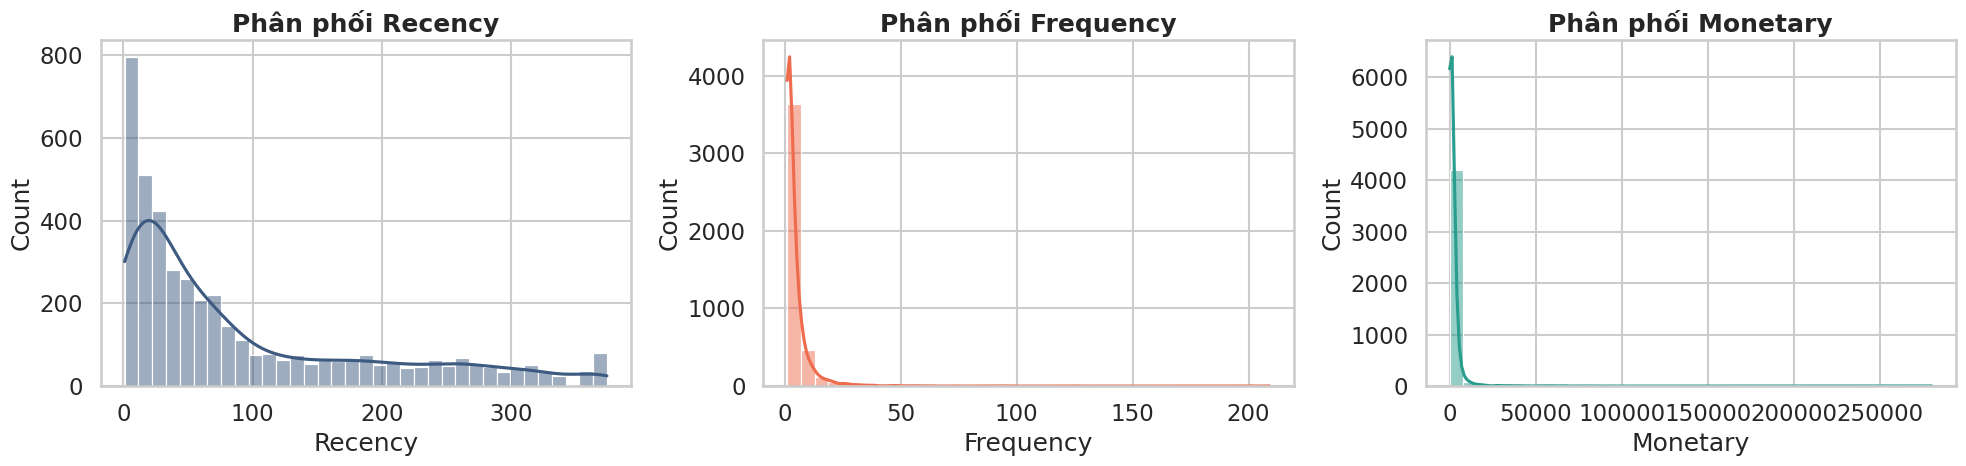

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors = ['#3D5A80', '#EE6C4D', '#2A9D8F']

for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], colors):
    sns.histplot(rfm_dataset[col], kde=True, bins=35, color=color, ax=ax)
    ax.set_title(f'Phân phối {col}')

plt.tight_layout()
plt.show()

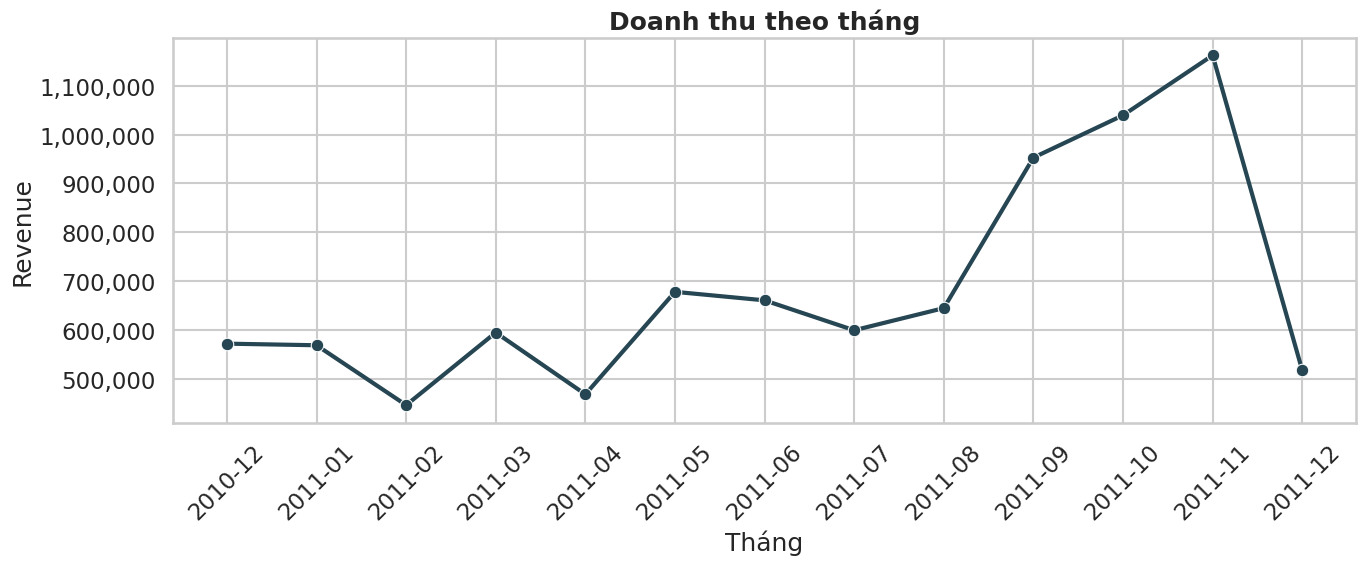

In [8]:
# ====================== 8. PHÂN TÍCH XU HƯỚNG MUA HÀNG ======================
monthly_sales = (
    dataset.assign(YearMonth=dataset['InvoiceDate'].dt.to_period('M').astype(str))
    .groupby('YearMonth')
    .agg(Revenue=('TotalAmount', 'sum'), Orders=('InvoiceNo', 'nunique'))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Revenue', marker='o', linewidth=3, color='#264653', ax=ax1)
ax1.set_title('Doanh thu theo tháng')
ax1.set_xlabel('Tháng')
ax1.set_ylabel('Revenue')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [9]:
# ====================== 9. CHUẨN HÓA DỮ LIỆU & CHỌN SỐ CỤM ======================
X_scaled = standardize_features(rfm_dataset)
metrics_df = evaluate_k_range(X_scaled, range(2, 9))
display(metrics_df)

best_k = int(metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k'])
print(f'Số cụm tốt nhất theo silhouette score: k = {best_k}')

,k,inertia,silhouette
0,2,"6,481.22",0.43
1,3,"4,867.76",0.34
2,4,"3,938.03",0.34
3,5,"3,295.82",0.32
4,6,"2,855.02",0.31
5,7,"2,548.90",0.31
6,8,"2,336.74",0.30


Số cụm tốt nhất theo silhouette score: k = 2


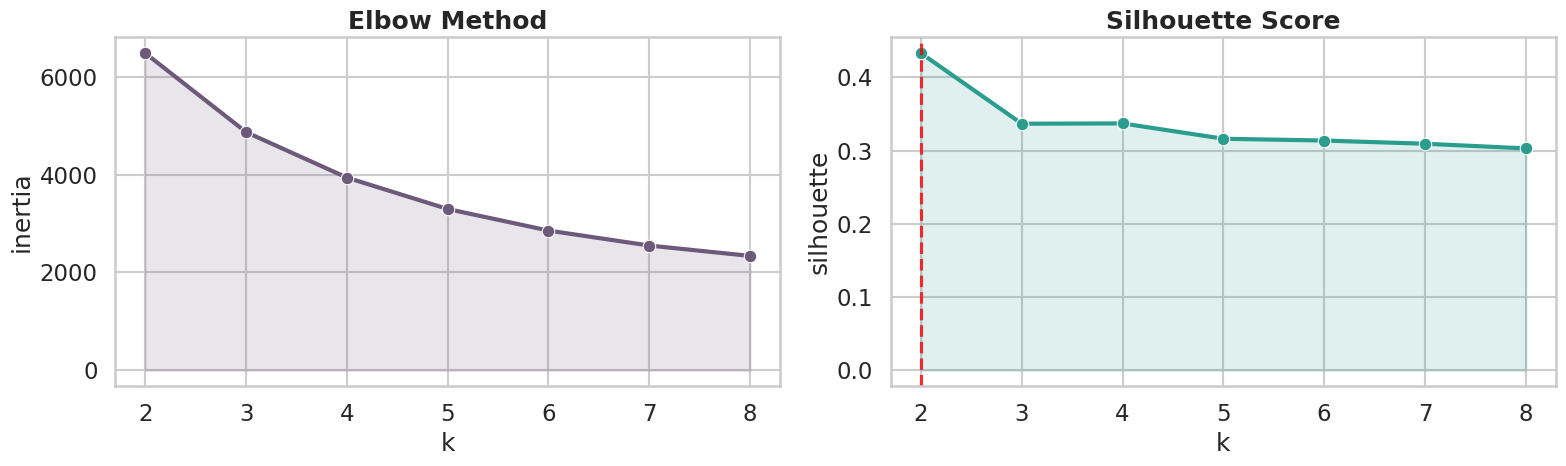

In [10]:
# Biểu đồ Elbow và Silhouette
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=metrics_df, x='k', y='inertia', marker='o', linewidth=3, color='#6D597A', ax=axes[0])
axes[0].fill_between(metrics_df['k'], metrics_df['inertia'], alpha=0.15, color='#6D597A')
axes[0].set_title('Elbow Method')

sns.lineplot(data=metrics_df, x='k', y='silhouette', marker='o', linewidth=3, color='#2A9D8F', ax=axes[1])
axes[1].fill_between(metrics_df['k'], metrics_df['silhouette'], alpha=0.15, color='#2A9D8F')
axes[1].axvline(best_k, linestyle='--', color='red', alpha=0.8)
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()

In [11]:
# ====================== 10. HUẤN LUYỆN MÔ HÌNH K-MEANS ======================
labels, centroids, inertia = run_kmeans(X_scaled, best_k)
rfm_dataset['Cluster'] = labels
cluster_profile = build_cluster_profile(rfm_dataset)

print('=== HỒ SƠ CỤM KHÁCH HÀNG ===')
display(cluster_profile)

=== HỒ SƠ CỤM KHÁCH HÀNG ===


,Cluster,Customers,AvgRecency,AvgFrequency,AvgMonetary,MedianMonetary
0,1,1667,25.88,8.44,"4,548.26","2,064.95"
1,0,2671,134.14,1.67,497.74,363.88


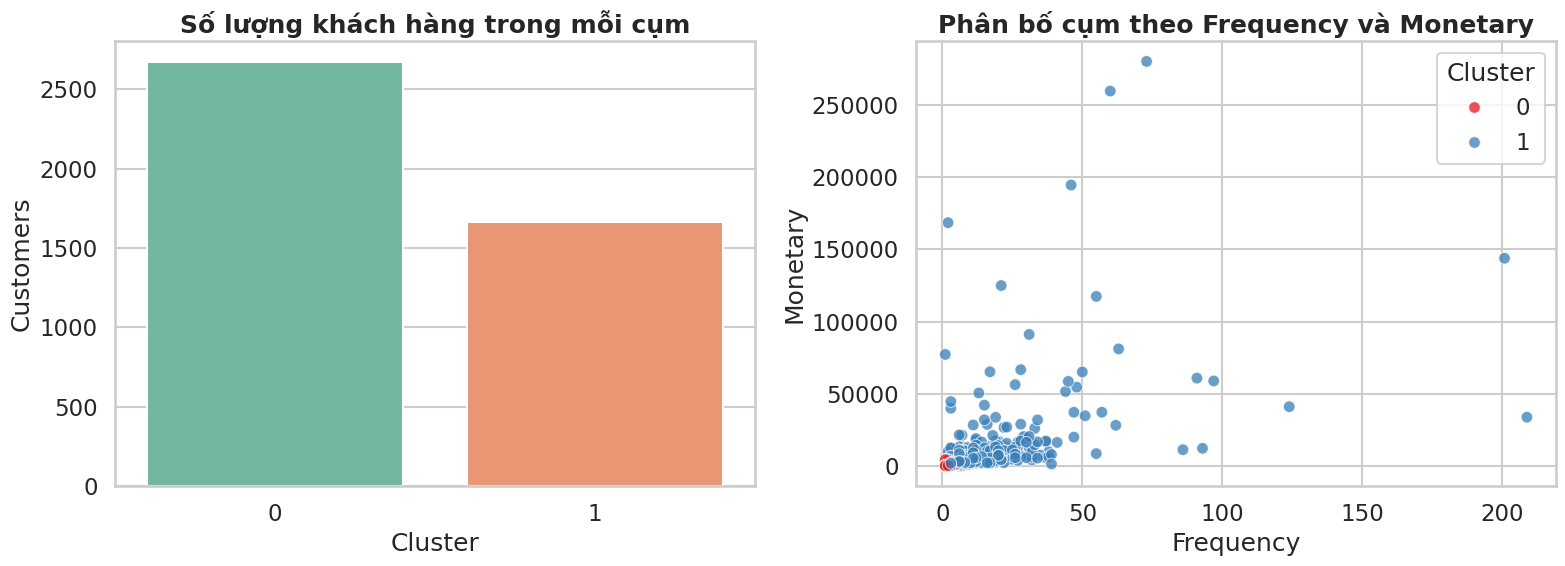

In [12]:
# ====================== 11. ĐÁNH GIÁ & TRỰC QUAN HÓA CỤM ======================
cluster_counts = rfm_dataset['Cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['Cluster', 'Customers']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=cluster_counts, x='Cluster', y='Customers', palette='Set2', ax=axes[0])
axes[0].set_title('Số lượng khách hàng trong mỗi cụm')

sns.scatterplot(
    data=rfm_dataset,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set1',
    alpha=0.75,
    s=70,
    ax=axes[1]
)
axes[1].set_title('Phân bố cụm theo Frequency và Monetary')

plt.tight_layout()
plt.show()

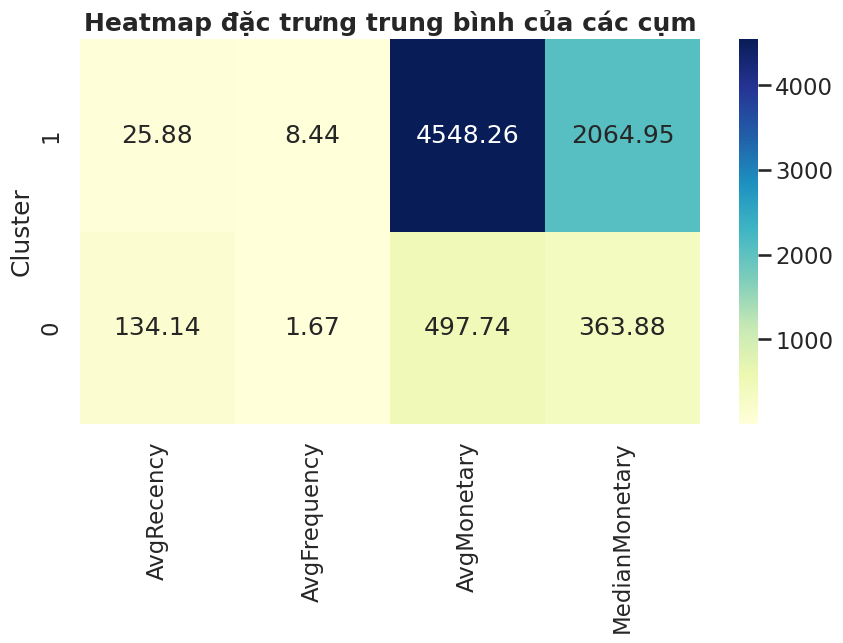

In [13]:
# Heatmap hồ sơ cụm
heatmap_df = cluster_profile.set_index('Cluster')[['AvgRecency', 'AvgFrequency', 'AvgMonetary', 'MedianMonetary']]
plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Heatmap đặc trưng trung bình của các cụm')
plt.show()

In [14]:
# ====================== 12. KHÁCH HÀNG GIẢ ĐỊNH ======================
sample_customer = pd.DataFrame([
    {'CustomerID': 'NEW_CUSTOMER', 'Recency': 12, 'Frequency': 9, 'Monetary': 4200.0}
])

reference = pd.concat([
    rfm_dataset[['CustomerID', 'Recency', 'Frequency', 'Monetary']],
    sample_customer,
], ignore_index=True)

reference_scaled = standardize_features(reference)
sample_scaled = reference_scaled[-1]
distance_to_centroids = np.linalg.norm(centroids - sample_scaled, axis=1)
predicted_cluster = int(np.argmin(distance_to_centroids))

print('=== DỰ ĐOÁN CỤM CHO KHÁCH HÀNG GIẢ ĐỊNH ===')
display(sample_customer)
print(f'Khách hàng giả định được gán vào cụm: {predicted_cluster}')
display(cluster_profile[cluster_profile['Cluster'] == predicted_cluster])

=== DỰ ĐOÁN CỤM CHO KHÁCH HÀNG GIẢ ĐỊNH ===


,CustomerID,Recency,Frequency,Monetary
0,NEW_CUSTOMER,12,9,"4,200.00"


Khách hàng giả định được gán vào cụm: 1


,Cluster,Customers,AvgRecency,AvgFrequency,AvgMonetary,MedianMonetary
0,1,1667,25.88,8.44,"4,548.26","2,064.95"


In [15]:
# ====================== 13. DỰ ĐOÁN XU HƯỚNG TIÊU DÙNG ======================
trend_transactions = load_clean_transactions(DATA_PATH)
monthly_trend = build_monthly_features(trend_transactions)
forecast_df, slopes = build_forecast_table(monthly_trend, steps=3)

print('=== DỮ LIỆU THEO THÁNG ===')
display(monthly_trend[['MonthLabel', 'Revenue', 'Orders', 'ActiveCustomers', 'Quantity']])

print('=== DỰ BÁO 3 THÁNG TIẾP THEO ===')
display(forecast_df[['MonthLabel', 'Revenue', 'Orders', 'ActiveCustomers', 'Quantity']])

for metric, slope in slopes.items():
    print(f'{metric}: {classify_trend(slope)} ({slope:,.2f}/tháng)')

=== DỮ LIỆU THEO THÁNG ===


,MonthLabel,Revenue,Orders,ActiveCustomers,Quantity
0,2010-12,"572,713.89",1400,885,312265
1,2011-01,"569,445.04",987,741,349098
2,2011-02,"447,137.35",997,758,265622
3,2011-03,"595,500.76",1321,974,348503
4,2011-04,"469,200.36",1149,856,292222
5,2011-05,"678,594.56",1555,1056,373601
6,2011-06,"661,213.69",1393,991,363699
7,2011-07,"600,091.01",1331,949,369420
8,2011-08,"645,343.90",1280,935,398121
9,2011-09,"952,838.38",1755,1266,544897


=== DỰ BÁO 3 THÁNG TIẾP THEO ===


,MonthLabel,Revenue,Orders,ActiveCustomers,Quantity
0,2011-12,"1,037,466.78","2,111.09","1,440.02","601,076.53"
1,2012-01,"1,089,471.73","2,208.26","1,502.08","630,980.62"
2,2012-02,"1,141,476.68","2,305.43","1,564.15","660,884.72"


Revenue: Tăng (52,004.95/tháng)
Orders: Tăng (97.17/tháng)
ActiveCustomers: Tăng (62.07/tháng)
Quantity: Tăng (29,904.09/tháng)


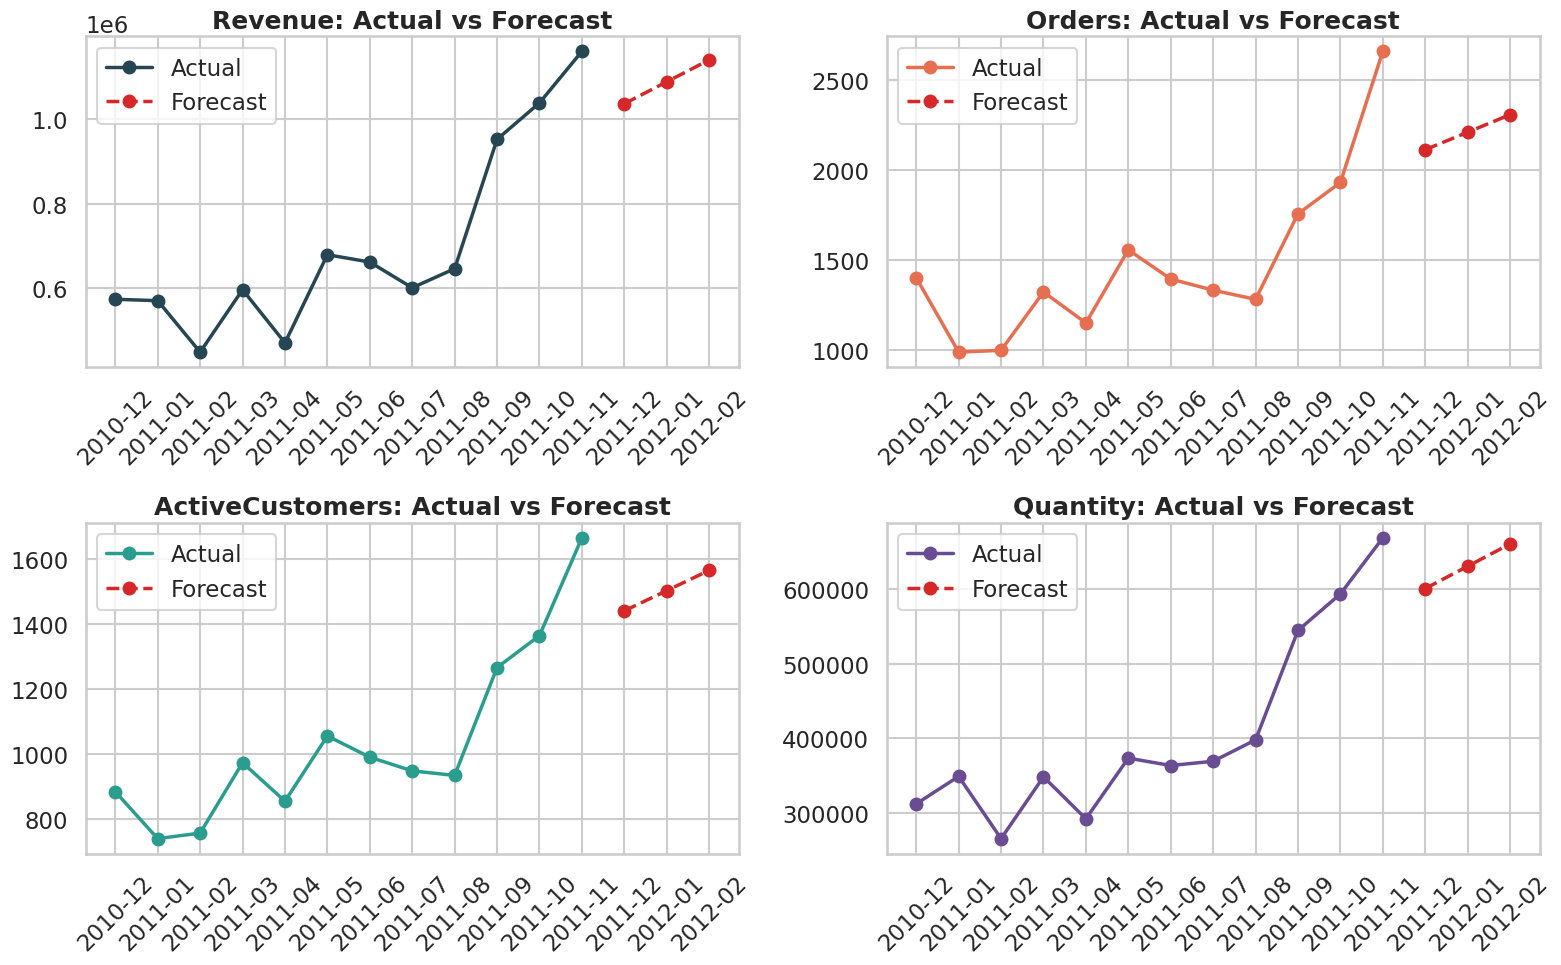

In [16]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = ['Revenue', 'Orders', 'ActiveCustomers', 'Quantity']
colors = ['#264653', '#E76F51', '#2A9D8F', '#6A4C93']

for ax, metric, color in zip(axes.flatten(), metrics, colors):
    ax.plot(monthly_trend['MonthLabel'], monthly_trend[metric], marker='o', linewidth=2.5, color=color, label='Actual')
    ax.plot(forecast_df['MonthLabel'], forecast_df[metric], marker='o', linestyle='--', linewidth=2.5, color='#D62828', label='Forecast')
    ax.set_title(f'{metric}: Actual vs Forecast')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.tight_layout()
plt.show()